# Análise exploratória de dados
- Projeto: **MITHA - Mini Tomato Hydration Assistant**
- Disciplina: **Projeto Integrador IV**
- Conjuntos de dados processados: safras **2023, 2024 e 2025**
---


## PRÉ-INÍCIO
- Carregamento das bibliotecas
- Leitura dos conjuntos de dados processados
- Organização das safras para análise


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


In [2]:
# @title Leitura dos conjuntos de dados

DATA_DIR = Path("../data/processed")

arquivos = {
    "2023": DATA_DIR / "dataset_m2_2023.csv",
    "2024": DATA_DIR / "dataset_m2_2024.csv",
    "2025": DATA_DIR / "dataset_m2_2025.csv",
}

datasets = {}

for safra, caminho in arquivos.items():
    if not caminho.exists():
        raise FileNotFoundError(
            f"Arquivo não encontrado: {caminho}\n"
            "Execute primeiro o script merge_m2.py."
        )

    df = pd.read_csv(caminho, low_memory=False)
    df["timestamp_10min"] = pd.to_datetime(
        df["timestamp_10min"], errors="coerce", utc=True
    )
    datasets[safra] = df

    print(f"Safra {safra}: {df.shape[0]:,} linhas × {df.shape[1]} colunas")


Safra 2023: 32,877 linhas × 19 colunas
Safra 2024: 46,635 linhas × 19 colunas
Safra 2025: 86,590 linhas × 19 colunas


## LIMPEZA E PREPARAÇÃO DOS DADOS

Nesta etapa, primeiro são inspecionados os dados **sem remover automaticamente outliers ou valores ausentes**.

O objetivo é compreender a qualidade dos dados antes de decidir quais tratamentos serão necessários para o modelo.


In [3]:
# @title Informações iniciais

for safra, df in datasets.items():
    display(Markdown(f"### Safra {safra}"))
    print(f"Dimensão: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

    display(Markdown("#### Primeiras linhas"))
    display(df.head())

    display(Markdown("#### Tipos das variáveis"))
    display(
        pd.DataFrame({
            "tipo": df.dtypes.astype(str),
            "valores_unicos": df.nunique(dropna=True),
            "nulos": df.isna().sum(),
        })
    )


### Safra 2023

Dimensão: 32,877 linhas × 19 colunas


#### Primeiras linhas

,timestamp_10min,timestamp_ms,line,env_temperature,env_humidity,env_co2,env_pressure,soil_temperature,soil_humidity,soil_ec,valve_state,water_volume,gdd,daily_mean_temperature,sdd,ontario_units,daily_max,daily_max_above_tbase,daily_max_reduction
0,2023-06-29 06:10:00+00:00,1688019000000,1,24.500,61.000,635.000,"1,010.700",23.500,28.450,346.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-06-29 06:10:00+00:00,1688019000000,2,24.500,61.000,635.000,"1,010.700",NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-06-29 06:10:00+00:00,1688019000000,3,24.500,61.000,635.000,"1,010.700",NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-06-29 13:00:00+00:00,1688043600000,1,41.200,39.500,472.000,"1,010.900",26.200,24.800,199.000,0.000,0.000,21.800,31.800,21.800,27.400,41.200,31.200,12.800
4,2023-06-29 13:00:00+00:00,1688043600000,2,41.200,39.500,472.000,"1,010.900",NaN,NaN,NaN,0.000,0.000,21.800,31.800,21.800,27.400,41.200,31.200,12.800


#### Tipos das variáveis

...

Dimensão: 86,590 linhas × 19 colunas


#### Primeiras linhas

,timestamp_10min,timestamp_ms,line,env_temperature,env_humidity,env_co2,env_pressure,soil_temperature,soil_humidity,soil_ec,valve_state,water_volume,gdd,daily_mean_temperature,sdd,ontario_units,daily_max,daily_max_above_tbase,daily_max_reduction
0,2025-06-26 05:50:00+00:00,1750917000000,1,26.200,58.500,535.000,"1,007.900",26.650,43.985,667.500,0.000,"16,666.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-06-26 05:50:00+00:00,1750917000000,2,26.200,58.500,535.000,"1,007.900",27.050,51.740,"1,020.500",0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-06-26 05:50:00+00:00,1750917000000,3,26.200,58.500,535.000,"1,007.900",28.100,41.470,809.500,0.000,"17,084.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-06-26 05:50:00+00:00,1750917000000,4,26.200,58.500,535.000,"1,007.900",24.500,46.205,"1,016.000",0.000,"65,394.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-06-26 05:50:00+00:00,1750917000000,5,26.200,58.500,535.000,"1,007.900",28.100,38.890,705.000,NaN,"7,526.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Tipos das variáveis

,tipo,valores_unicos,nulos
timestamp_10min,"datetime64[ns, UTC]",17318,0
timestamp_ms,int64,17318,0
line,int64,5,0
env_temperature,float64,291,0
env_humidity,float64,137,0
env_co2,float64,695,0
env_pressure,float64,343,0
soil_temperature,float64,310,182
soil_humidity,float64,4828,182
soil_ec,float64,2232,182


In [4]:
# @title Dicionário de dados

df_dict = pd.DataFrame([
    {
        "variavel": "timestamp_10min",
        "descricao": "Instante da observação agrupado em janelas de 10 minutos.",
        "tipo": "temporal",
        "papel": "identificação",
    },
    {
        "variavel": "timestamp_ms",
        "descricao": "Timestamp equivalente em milissegundos.",
        "tipo": "quantitativa",
        "papel": "identificação",
    },
    {
        "variavel": "line",
        "descricao": "Linha de cultivo à qual a observação está associada.",
        "tipo": "qualitativa/discreta",
        "papel": "identificação/contexto",
    },
    {
        "variavel": "env_temperature",
        "descricao": "Temperatura do ar em graus Celsius.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "env_humidity",
        "descricao": "Umidade relativa do ar em porcentagem.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "env_co2",
        "descricao": "Concentração de CO₂ no ambiente em ppm.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "env_pressure",
        "descricao": "Pressão barométrica em hPa.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "soil_temperature",
        "descricao": "Temperatura do solo em graus Celsius.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "soil_humidity",
        "descricao": "Umidade do solo.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "soil_ec",
        "descricao": "Condutividade elétrica do solo em µS/cm.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "valve_state",
        "descricao": "Estado da válvula: 0 = fechada e 1 = aberta.",
        "tipo": "qualitativa binária",
        "papel": "alvo",
    },
    {
        "variavel": "water_volume",
        "descricao": "Leitura de volume de água proveniente do medidor.",
        "tipo": "quantitativa contínua",
        "papel": "contexto (avaliar possível vazamento de informação)",
    },
    {
        "variavel": "gdd",
        "descricao": "Graus-dia acumulados (Growing Degree Days).",
        "tipo": "quantitativa contínua",
        "papel": "preditora/contexto",
    },
    {
        "variavel": "daily_mean_temperature",
        "descricao": "Temperatura média diária em graus Celsius.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "sdd",
        "descricao": "Standard Day Degree.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "ontario_units",
        "descricao": "Ontario Units calculadas para a safra.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "daily_max",
        "descricao": "Temperatura máxima diária.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "daily_max_above_tbase",
        "descricao": "Temperatura máxima diária acima da temperatura-base.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
    {
        "variavel": "daily_max_reduction",
        "descricao": "Indicador de temperatura máxima com aplicação do cutoff.",
        "tipo": "quantitativa contínua",
        "papel": "preditora",
    },
])

display(df_dict)


,variavel,descricao,tipo,papel
0,timestamp_10min,Instante da observação agrupado em janelas de ...,temporal,identificação
1,timestamp_ms,Timestamp equivalente em milissegundos.,quantitativa,identificação
2,line,Linha de cultivo à qual a observação está asso...,qualitativa/discreta,identificação/contexto
3,env_temperature,Temperatura do ar em graus Celsius.,quantitativa contínua,preditora
4,env_humidity,Umidade relativa do ar em porcentagem.,quantitativa contínua,preditora
5,env_co2,Concentração de CO₂ no ambiente em ppm.,quantitativa contínua,preditora
6,env_pressure,Pressão barométrica em hPa.,quantitativa contínua,preditora
7,soil_temperature,Temperatura do solo em graus Celsius.,quantitativa contínua,preditora
8,soil_humidity,Umidade do solo.,quantitativa contínua,preditora
9,soil_ec,Condutividade elétrica do solo em µS/cm.,quantitativa contínua,preditora


In [5]:
# @title Análise de valores faltantes

missing_rows = []

for safra, df in datasets.items():
    for coluna in df.columns:
        qtd = int(df[coluna].isna().sum())
        missing_rows.append({
            "safra": safra,
            "variavel": coluna,
            "nulos": qtd,
            "nulos_%": 100 * qtd / len(df),
        })

missing = pd.DataFrame(missing_rows)
missing = missing.sort_values(["safra", "nulos_%"], ascending=[True, False])

display(
    missing[missing["nulos"] > 0]
    .style.format({"nulos_%": "{:.2f}%"})
)


,safra,variavel,nulos,nulos_%
10,2023,valve_state,1387,4.22%
11,2023,water_volume,602,1.83%
7,2023,soil_temperature,418,1.27%
8,2023,soil_humidity,418,1.27%
9,2023,soil_ec,418,1.27%
12,2023,gdd,3,0.01%
13,2023,daily_mean_temperature,3,0.01%
14,2023,sdd,3,0.01%
15,2023,ontario_units,3,0.01%
16,2023,daily_max,3,0.01%


In [6]:
# @title Verificação de duplicatas

for safra, df in datasets.items():
    duplicatas = int(df.duplicated().sum())
    print(f"Safra {safra}: {duplicatas:,} linhas completamente duplicadas.")


Safra 2023: 0 linhas completamente duplicadas.
Safra 2024: 0 linhas completamente duplicadas.
Safra 2025: 0 linhas completamente duplicadas.


## DEFINIÇÃO E ANÁLISE DA VARIÁVEL DE CLASSE

O problema é tratado inicialmente como **classificação binária**.

A variável alvo é `valve_state`:

- `0`: válvula fechada;
- `1`: válvula aberta.

Diferentemente do notebook de referência, **não é necessário discretizar a variável-alvo**, pois ela já é binária.

Também é importante analisar separadamente os valores ausentes da classe. Eles não devem ser convertidos automaticamente para `0` sem confirmar o significado dos registros no dataset original.


In [7]:
# @title Distribuição da variável-alvo por safra

distribuicoes = []

for safra, df in datasets.items():
    total = len(df)
    conhecidos = df["valve_state"].notna().sum()
    ausentes = df["valve_state"].isna().sum()

    contagem = df["valve_state"].value_counts(dropna=True).sort_index()

    fechada = int(contagem.get(0, 0))
    aberta = int(contagem.get(1, 0))

    distribuicoes.append({
        "safra": safra,
        "total_linhas": total,
        "classe_conhecida": conhecidos,
        "classe_ausente": ausentes,
        "fechada_0": fechada,
        "aberta_1": aberta,
        "aberta_%_entre_validos": 100 * aberta / conhecidos if conhecidos else np.nan,
    })

class_distribution = pd.DataFrame(distribuicoes)
display(
    class_distribution.style.format({
        "aberta_%_entre_validos": "{:.2f}%"
    })
)


,safra,total_linhas,classe_conhecida,classe_ausente,fechada_0,aberta_1,aberta_%_entre_validos
0,2023,32877,31490,1387,1351,30139,95.71%
1,2024,46635,46218,417,45523,695,1.50%
2,2025,86590,78890,7700,78480,410,0.52%


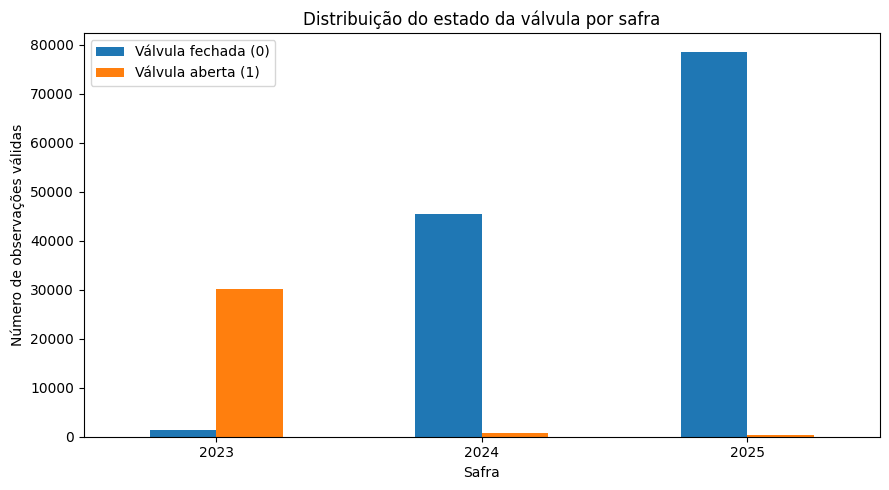

In [8]:
# @title Visualização da distribuição da classe

plot_df = class_distribution.set_index("safra")[["fechada_0", "aberta_1"]]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("Distribuição do estado da válvula por safra")
ax.set_xlabel("Safra")
ax.set_ylabel("Número de observações válidas")
ax.legend(["Válvula fechada (0)", "Válvula aberta (1)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


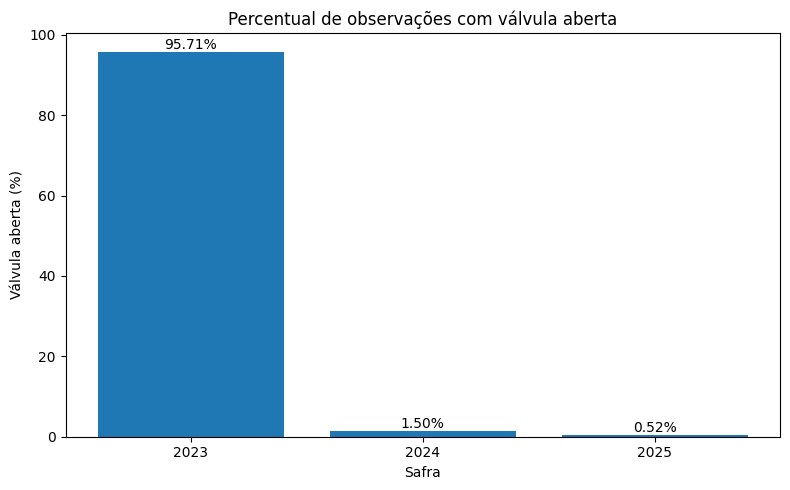

In [9]:
# @title Percentual de válvula aberta por safra

x = class_distribution["safra"]
y = class_distribution["aberta_%_entre_validos"]

plt.figure(figsize=(8, 5))
plt.bar(x, y)
plt.title("Percentual de observações com válvula aberta")
plt.xlabel("Safra")
plt.ylabel("Válvula aberta (%)")

for i, valor in enumerate(y):
    plt.text(i, valor, f"{valor:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()


## DESCRIÇÃO FORMAL E ESTATÍSTICAS GERAIS


In [10]:
# @title Descrição formal dos conjuntos de dados

ID_COLS = {"timestamp_10min", "timestamp_ms", "line"}
TARGET = "valve_state"

for safra, df in datasets.items():
    preditoras = [
        c for c in df.columns
        if c not in ID_COLS and c != TARGET
    ]

    N = len(df)
    D = len(preditoras)
    L = df[TARGET].dropna().nunique()

    print(
        f"Safra {safra}: N = {N:,} observações, "
        f"D = {D} variáveis candidatas e L = {L} classes conhecidas."
    )


Safra 2023: N = 32,877 observações, D = 15 variáveis candidatas e L = 2 classes conhecidas.
Safra 2024: N = 46,635 observações, D = 15 variáveis candidatas e L = 2 classes conhecidas.
Safra 2025: N = 86,590 observações, D = 15 variáveis candidatas e L = 2 classes conhecidas.


In [11]:
# @title Estatísticas descritivas por safra

for safra, df in datasets.items():
    display(Markdown(f"### Safra {safra}"))

    numericas = df.select_dtypes(include=np.number).columns
    stats = df[numericas].describe().T
    stats["mediana"] = df[numericas].median()
    stats["nulos"] = df[numericas].isna().sum()
    stats["nulos_%"] = 100 * stats["nulos"] / len(df)

    cols = [
        "count", "nulos", "nulos_%",
        "mean", "mediana", "std", "min", "25%", "75%", "max"
    ]

    display(stats[cols])


### Safra 2023

,count,nulos,nulos_%,mean,mediana,std,min,25%,75%,max
timestamp_ms,"32,877.000",0,0.000,"1,691,340,743,388.995","1,691,340,000,000.000","1,905,385,232.217","1,688,019,000,000.000","1,689,690,000,000.000","1,692,990,600,000.000","1,694,641,800,000.000"
line,"32,877.000",0,0.000,2.000,2.000,0.817,1.000,1.000,3.000,3.000
env_temperature,"32,877.000",0,0.000,26.920,26.100,7.234,10.100,20.800,33.100,43.700
env_humidity,"32,877.000",0,0.000,58.069,57.000,18.223,18.000,42.500,74.000,97.000
env_co2,"32,877.000",0,0.000,481.347,470.000,48.029,396.000,448.000,503.000,858.000
env_pressure,"32,877.000",0,0.000,"1,009.800","1,010.500",5.249,993.700,"1,006.700","1,013.600","1,019.400"
soil_temperature,"32,459.000",418,1.271,23.977,23.800,2.061,19.600,22.600,25.100,32.600
soil_humidity,"32,459.000",418,1.271,25.786,23.410,7.608,0.000,20.750,28.280,56.810
soil_ec,"32,459.000",418,1.271,374.732,295.000,275.189,0.000,169.000,464.000,"1,767.000"
valve_state,"31,490.000",1387,4.219,0.957,1.000,0.203,0.000,1.000,1.000,1.000


### Safra 2024

,count,nulos,nulos_%,mean,mediana,std,min,25%,75%,max
timestamp_ms,"46,635.000",0,0.000,"1,722,002,020,842.715","1,722,507,600,000.000","2,349,858,085.580","1,718,150,400,000.000","1,719,582,600,000.000","1,724,094,000,000.000","1,725,503,400,000.000"
line,"46,635.000",0,0.000,3.000,3.000,1.414,1.000,2.000,4.000,5.000
env_temperature,"46,635.000",0,0.000,26.659,25.500,6.494,13.500,21.300,32.200,41.200
env_humidity,"46,625.000",10,0.021,67.220,66.000,18.804,24.000,51.000,82.000,100.000
env_co2,"46,635.000",0,0.000,493.755,483.000,53.422,396.000,458.000,512.000,814.000
env_pressure,"29,105.000",17530,37.590,"1,008.221","1,008.200",3.014,"1,000.800","1,006.100","1,010.600","1,015.200"
soil_temperature,"46,622.000",13,0.028,24.951,24.950,1.462,12.200,23.900,26.050,43.000
soil_humidity,"46,622.000",13,0.028,24.436,25.350,6.584,0.000,19.130,28.755,338.040
soil_ec,"46,622.000",13,0.028,344.126,339.000,268.809,0.000,235.000,447.375,"32,906.000"
valve_state,"46,218.000",417,0.894,0.015,0.000,0.122,0.000,0.000,0.000,1.000


### Safra 2025

,count,nulos,nulos_%,mean,mediana,std,min,25%,75%,max
timestamp_ms,"86,590.000",0,0.000,"1,756,272,905,543.365","1,756,355,100,000.000","3,120,643,585.196","1,750,917,000,000.000","1,753,538,400,000.000","1,758,989,400,000.000","1,761,638,400,000.000"
line,"86,590.000",0,0.000,3.000,3.000,1.414,1.000,2.000,4.000,5.000
env_temperature,"86,590.000",0,0.000,23.820,22.700,5.237,10.300,19.700,26.900,40.500
env_humidity,"86,590.000",0,0.000,62.935,61.500,12.880,29.000,56.000,69.000,97.500
env_co2,"86,590.000",0,0.000,547.624,512.000,116.078,413.000,479.000,569.000,"1,634.000"
env_pressure,"86,590.000",0,0.000,"1,009.361","1,010.000",5.177,986.000,"1,006.300","1,012.700","1,023.100"
soil_temperature,"86,408.000",182,0.210,22.914,22.600,2.529,16.850,21.300,24.850,30.200
soil_humidity,"86,408.000",182,0.210,26.294,32.820,15.842,0.000,3.715,37.160,58.370
soil_ec,"86,408.000",182,0.210,453.084,548.500,326.453,0.000,0.000,676.500,"2,030.000"
valve_state,"78,890.000",7700,8.892,0.005,0.000,0.072,0.000,0.000,0.000,1.000


## DISTRIBUIÇÃO DAS VARIÁVEIS

Nesta etapa são observadas as distribuições das principais variáveis ambientais e de solo.

A comparação por safra é importante porque as condições de cultivo e a instrumentação podem variar entre 2023, 2024 e 2025.


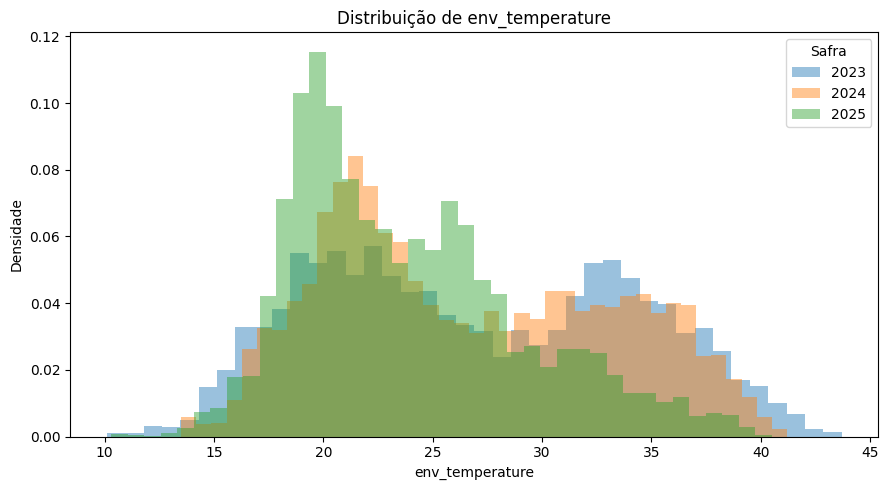

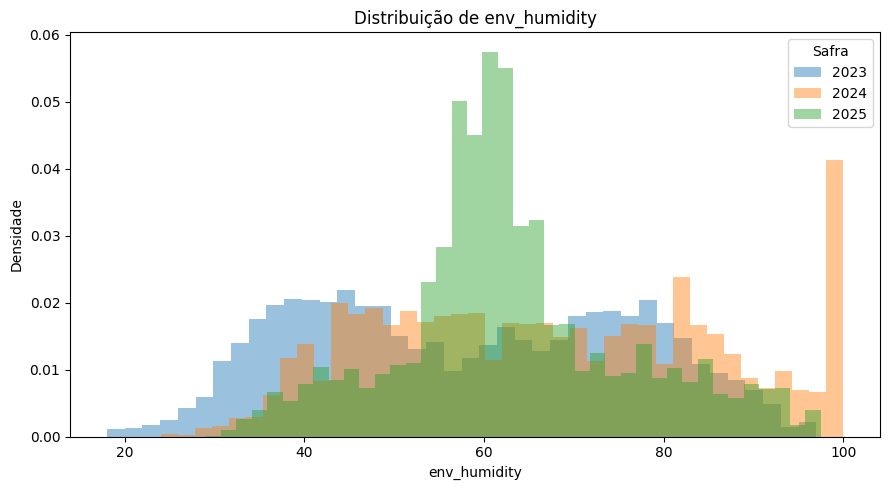

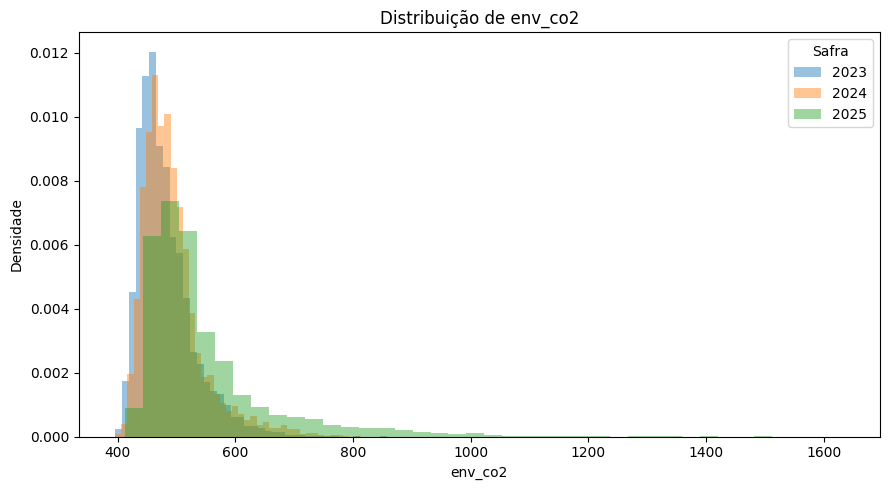

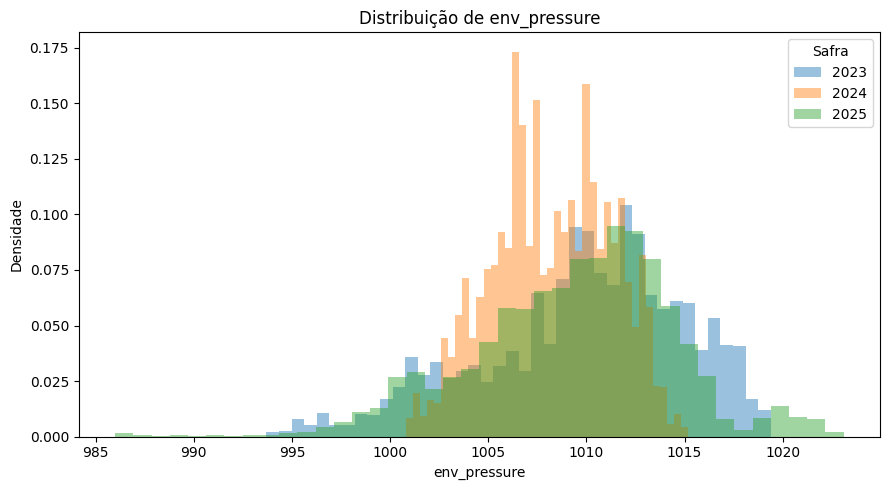

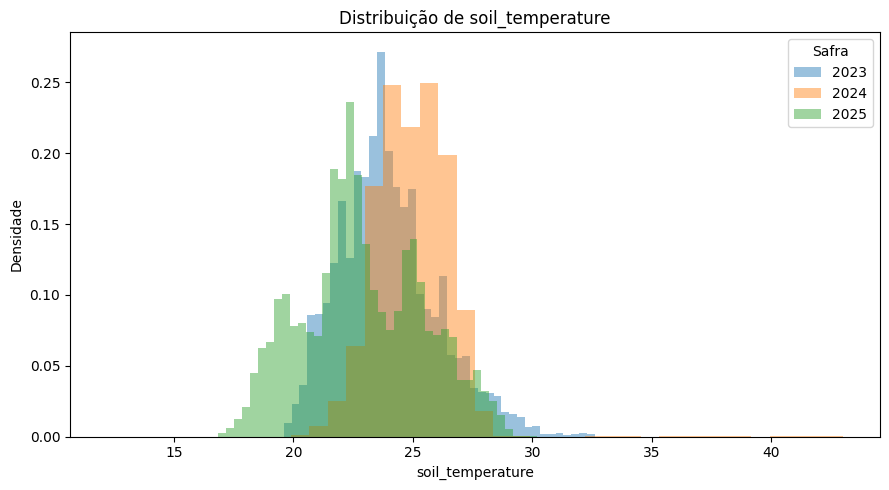

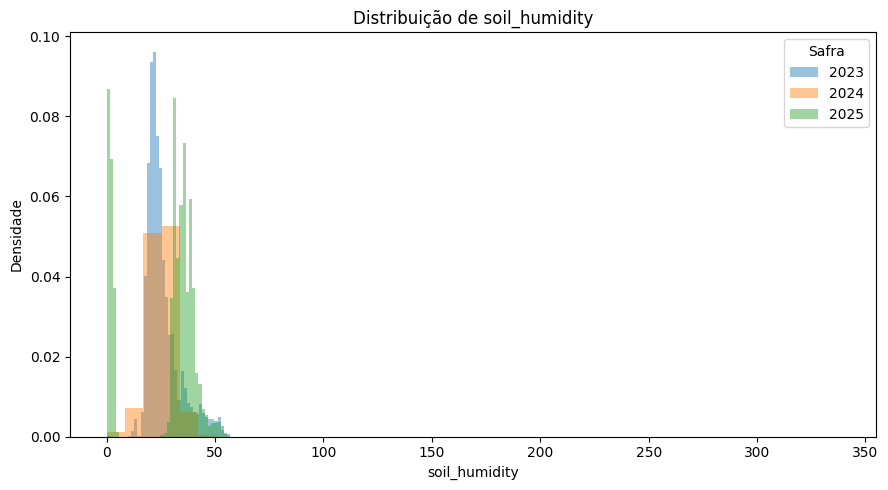

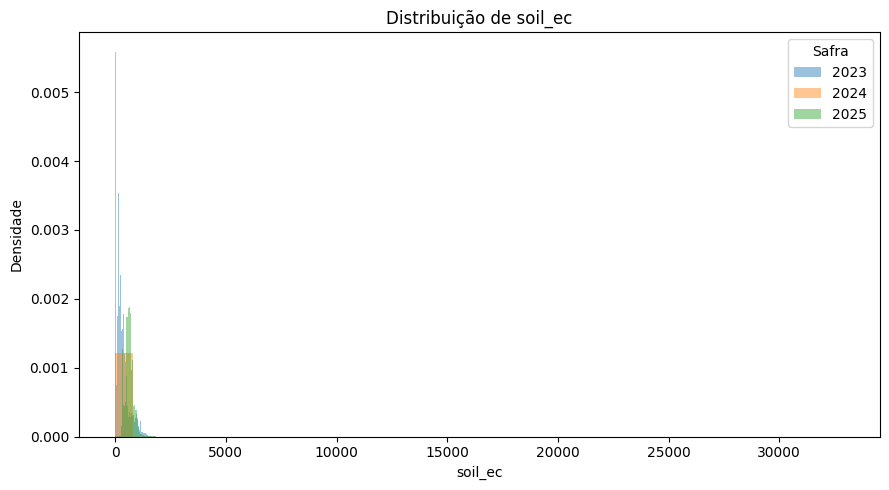

In [12]:
# @title Histogramas das principais variáveis

features_principais = [
    "env_temperature",
    "env_humidity",
    "env_co2",
    "env_pressure",
    "soil_temperature",
    "soil_humidity",
    "soil_ec",
]

for feature in features_principais:
    plt.figure(figsize=(9, 5))

    for safra, df in datasets.items():
        if feature in df.columns:
            serie = df[feature].dropna()
            plt.hist(
                serie,
                bins=40,
                alpha=0.45,
                density=True,
                label=safra,
            )

    plt.title(f"Distribuição de {feature}")
    plt.xlabel(feature)
    plt.ylabel("Densidade")
    plt.legend(title="Safra")
    plt.tight_layout()
    plt.show()


## INVESTIGAÇÃO DE POSSÍVEIS OUTLIERS

Os valores extremos são inicialmente **identificados, não removidos**.

Antes de excluir qualquer observação, deve-se avaliar se o valor representa:

1. erro de sensor;
2. erro de integração/processamento;
3. uma condição real, porém rara, do cultivo.


In [14]:
# @title Resumo de possíveis outliers pelo método do IQR

features_outliers = [
    "env_temperature",
    "env_humidity",
    "env_co2",
    "env_pressure",
    "soil_temperature",
    "soil_humidity",
    "soil_ec",
]

outlier_rows = []

for safra, df in datasets.items():
    for feature in features_outliers:
        if feature not in df.columns:
            continue

        s = df[feature].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        limite_inf = q1 - 1.5 * iqr
        limite_sup = q3 + 1.5 * iqr

        mask = (s < limite_inf) | (s > limite_sup)

        outlier_rows.append({
            "safra": safra,
            "variavel": feature,
            "q1": q1,
            "q3": q3,
            "limite_inferior": limite_inf,
            "limite_superior": limite_sup,
            "possiveis_outliers": int(mask.sum()),
            "outliers_%": 100 * mask.mean(),
        })

outlier_summary = pd.DataFrame(outlier_rows)

display(
    outlier_summary.style.format({
        "outliers_%": "{:.2f}%"
    })
)


,safra,variavel,q1,q3,limite_inferior,limite_superior,possiveis_outliers,outliers_%
0,2023,env_temperature,20.800000,33.100000,2.350000,51.550000,0,0.00%
1,2023,env_humidity,42.500000,74.000000,-4.750000,121.250000,0,0.00%
2,2023,env_co2,448.000000,503.000000,365.500000,585.500000,1317,4.01%
3,2023,env_pressure,1006.700000,1013.600000,996.350000,1023.950000,399,1.21%
4,2023,soil_temperature,22.600000,25.100000,18.850000,28.850000,717,2.21%
5,2023,soil_humidity,20.750000,28.280000,9.455000,39.575000,2406,7.41%
6,2023,soil_ec,169.000000,464.000000,-273.500000,906.500000,2411,7.43%
7,2024,env_temperature,21.300000,32.200000,4.950000,48.550000,0,0.00%
8,2024,env_humidity,51.000000,82.000000,4.500000,128.500000,0,0.00%
9,2024,env_co2,458.000000,512.000000,377.000000,593.000000,2810,6.03%


C:\Users\dinow\AppData\Local\Temp\ipykernel_26340\2560075546.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=labels, showfliers=True)


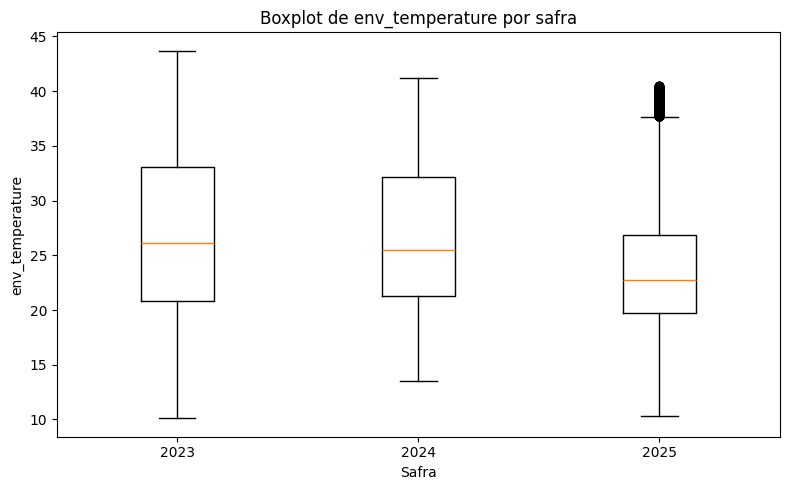

C:\Users\dinow\AppData\Local\Temp\ipykernel_26340\2560075546.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=labels, showfliers=True)


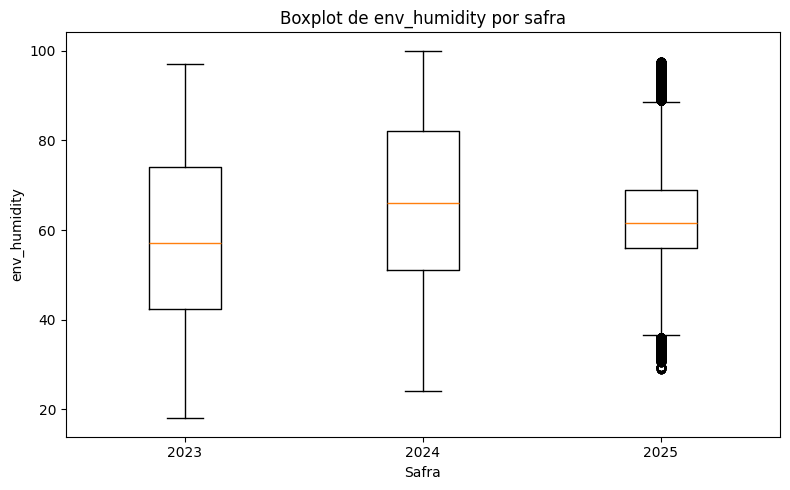

C:\Users\dinow\AppData\Local\Temp\ipykernel_26340\2560075546.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=labels, showfliers=True)


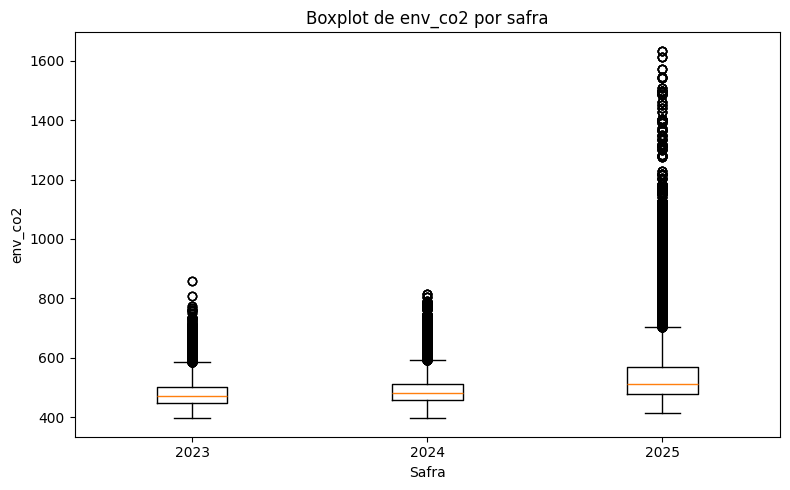

C:\Users\dinow\AppData\Local\Temp\ipykernel_26340\2560075546.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=labels, showfliers=True)


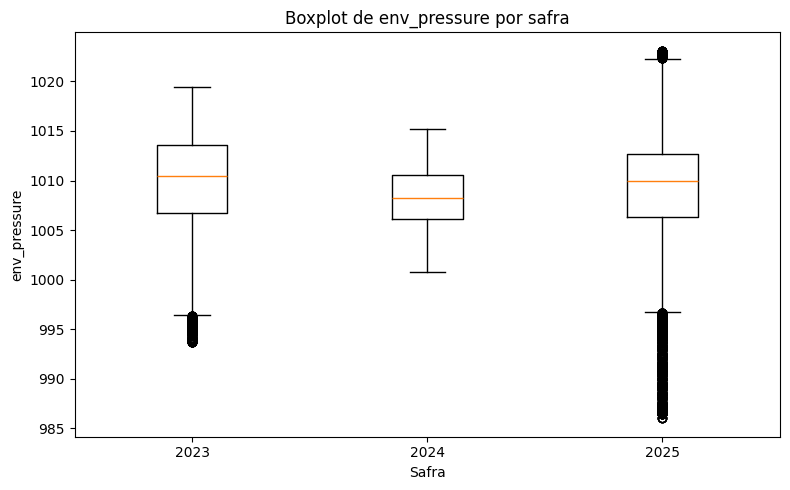

C:\Users\dinow\AppData\Local\Temp\ipykernel_26340\2560075546.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=labels, showfliers=True)


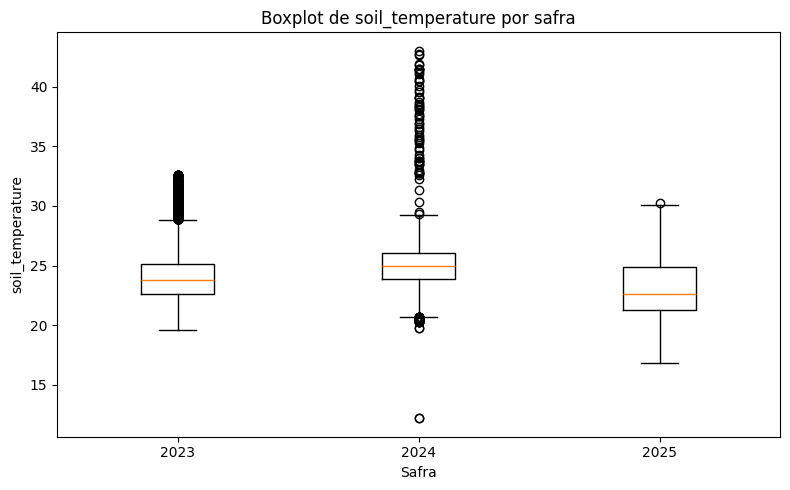

C:\Users\dinow\AppData\Local\Temp\ipykernel_26340\2560075546.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=labels, showfliers=True)


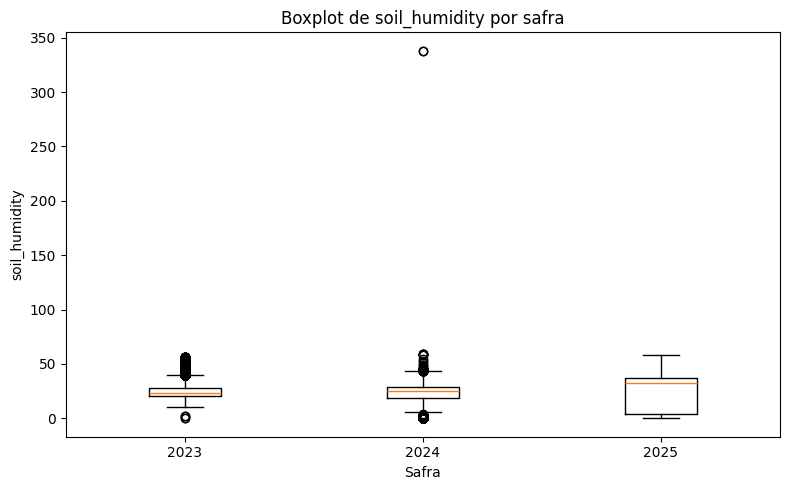

C:\Users\dinow\AppData\Local\Temp\ipykernel_26340\2560075546.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=labels, showfliers=True)


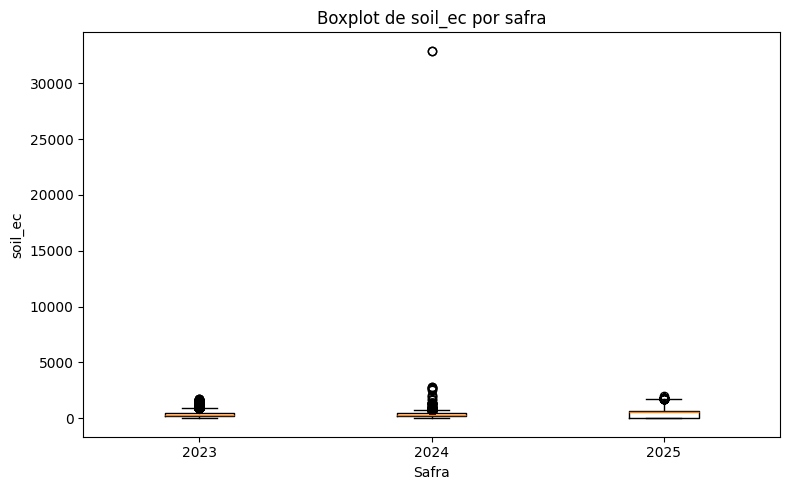

In [15]:
# @title Boxplots para inspeção visual

for feature in features_outliers:
    dados = []
    labels = []

    for safra, df in datasets.items():
        if feature in df.columns:
            serie = df[feature].dropna()
            dados.append(serie)
            labels.append(safra)

    if dados:
        plt.figure(figsize=(8, 5))
        plt.boxplot(dados, labels=labels, showfliers=True)
        plt.title(f"Boxplot de {feature} por safra")
        plt.xlabel("Safra")
        plt.ylabel(feature)
        plt.tight_layout()
        plt.show()


## RELAÇÃO ENTRE AS VARIÁVEIS E O ESTADO DA VÁLVULA

A análise abaixo compara os valores das variáveis quando a válvula está fechada (`0`) e aberta (`1`).

Essa etapa ajuda a verificar se as variáveis ambientais e de solo apresentam diferenças associadas ao acionamento da irrigação.


In [16]:
# @title Médias das variáveis por estado da válvula

features_modelo = [
    "env_temperature",
    "env_humidity",
    "env_co2",
    "env_pressure",
    "soil_temperature",
    "soil_humidity",
    "soil_ec",
]

for safra, df in datasets.items():
    cols = [c for c in features_modelo if c in df.columns]

    display(Markdown(f"### Safra {safra}"))
    display(
        df.dropna(subset=["valve_state"])
          .groupby("valve_state")[cols]
          .agg(["mean", "median"])
          .T
    )


### Safra 2023

valve_state                 0.000     1.000
env_temperature  mean      24.922    27.046
                 median    23.400    26.300
env_humidity     mean      69.117    57.367
                 median    68.500    56.500
env_co2          mean     499.660   480.265
                 median   486.000   469.000
env_pressure     mean   1,007.229 1,009.967
                 median 1,007.300 1,010.800
soil_temperature mean      25.390    23.888
                 median    25.200    23.700
soil_humidity    mean      27.565    25.246
                 median    27.020    23.140
soil_ec          mean     695.518   343.814
                 median   741.000   276.000

### Safra 2024

valve_state                 0.000     1.000
env_temperature  mean      26.548    33.440
                 median    25.300    33.300
env_humidity     mean      67.305    61.012
                 median    66.000    64.000
env_co2          mean     494.154   471.786
                 median   483.000   473.000
env_pressure     mean   1,008.203 1,008.996
                 median 1,008.200 1,009.800
soil_temperature mean      24.952    24.952
                 median    25.000    24.850
soil_humidity    mean      24.332    30.946
                 median    25.190    30.510
soil_ec          mean     341.768   503.545
                 median   338.000   484.000

### Safra 2025

valve_state                 0.000     1.000
env_temperature  mean      23.958    30.230
                 median    23.000    29.700
env_humidity     mean      63.251    52.091
                 median    62.000    52.000
env_co2          mean     540.925   500.815
                 median   508.000   468.000
env_pressure     mean   1,009.259 1,008.603
                 median 1,009.800 1,008.700
soil_temperature mean      23.017    24.608
                 median    22.750    24.750
soil_humidity    mean      27.620    37.607
                 median    33.510    34.400
soil_ec          mean     478.602   785.272
                 median   569.000   795.250

C:\Users\dinow\AppData\Local\Temp\ipykernel_26340\3386623639.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


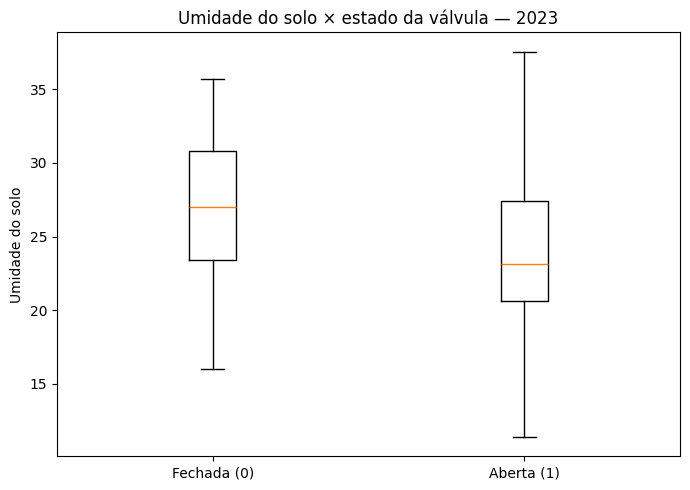

C:\Users\dinow\AppData\Local\Temp\ipykernel_26340\3386623639.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


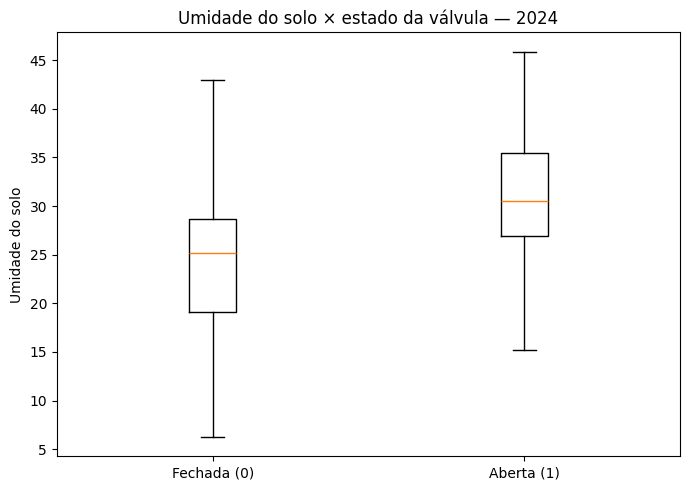

C:\Users\dinow\AppData\Local\Temp\ipykernel_26340\3386623639.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


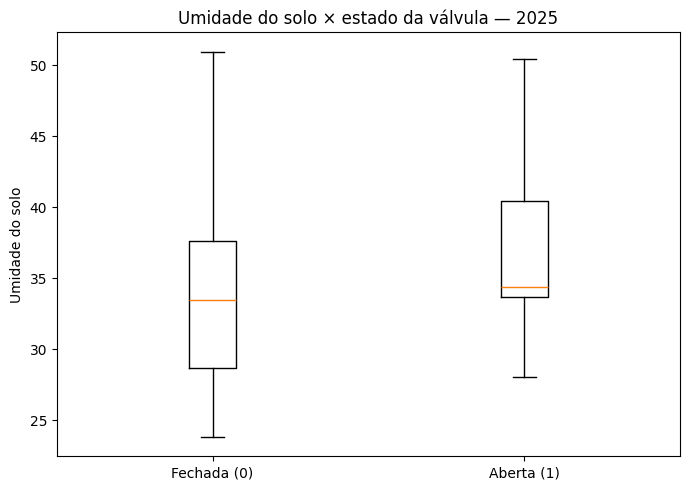

In [17]:
# @title Comparação da umidade do solo por estado da válvula

for safra, df in datasets.items():
    if "soil_humidity" not in df.columns:
        continue

    temp = df[["soil_humidity", "valve_state"]].dropna()

    fechada = temp.loc[temp["valve_state"] == 0, "soil_humidity"]
    aberta = temp.loc[temp["valve_state"] == 1, "soil_humidity"]

    if len(fechada) == 0 or len(aberta) == 0:
        continue

    plt.figure(figsize=(7, 5))
    plt.boxplot(
        [fechada, aberta],
        labels=["Fechada (0)", "Aberta (1)"],
        showfliers=False,
    )
    plt.title(f"Umidade do solo × estado da válvula — {safra}")
    plt.ylabel("Umidade do solo")
    plt.tight_layout()
    plt.show()


## CORRELAÇÃO ENTRE VARIÁVEIS

A correlação é utilizada apenas como análise exploratória de associação linear.

Variáveis derivadas umas das outras podem apresentar correlações elevadas. Isso deverá ser considerado posteriormente na seleção de atributos.


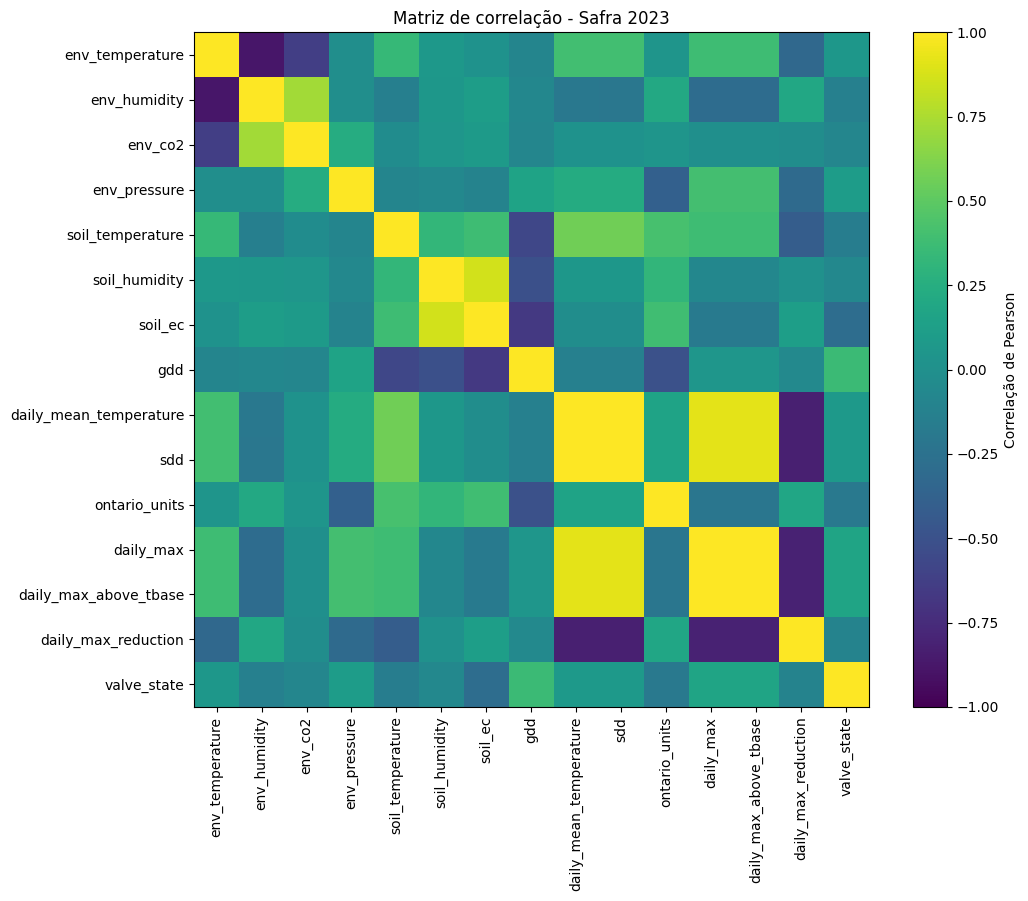

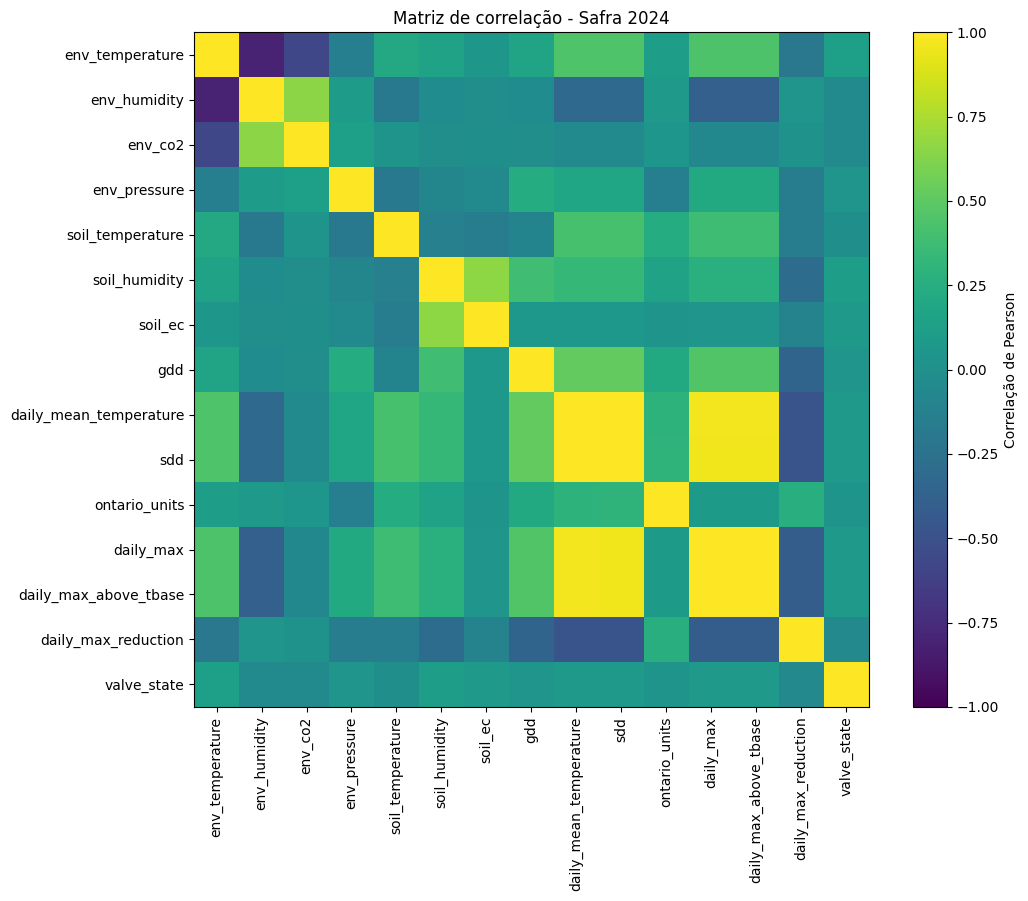

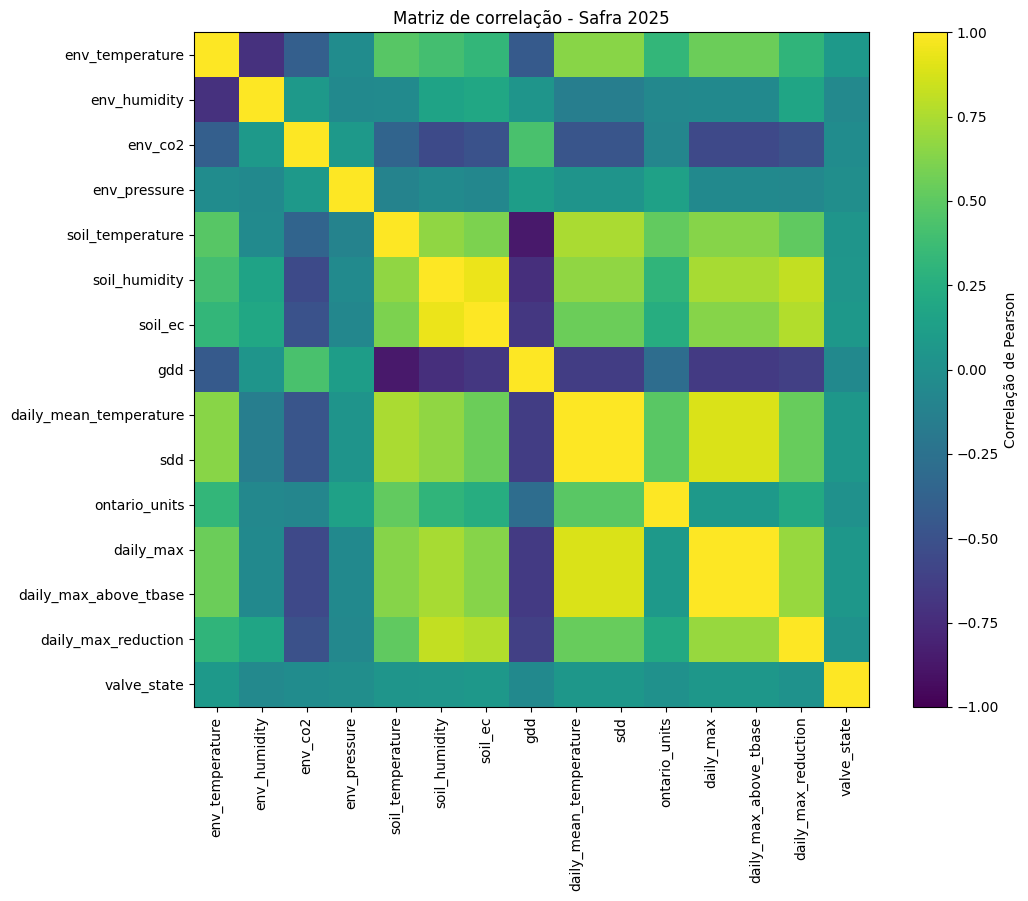

In [19]:
# @title Matriz de correlação por safra

corr_features = [
    "env_temperature",
    "env_humidity",
    "env_co2",
    "env_pressure",
    "soil_temperature",
    "soil_humidity",
    "soil_ec",
    "gdd",
    "daily_mean_temperature",
    "sdd",
    "ontario_units",
    "daily_max",
    "daily_max_above_tbase",
    "daily_max_reduction",
    "valve_state",
]

for safra, df in datasets.items():
    cols = [c for c in corr_features if c in df.columns]
    corr = df[cols].corr()

    fig, ax = plt.subplots(figsize=(11, 9))
    imagem = ax.imshow(corr, vmin=-1, vmax=1)

    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=90)
    ax.set_yticklabels(cols)

    fig.colorbar(imagem, ax=ax, label="Correlação de Pearson")
    ax.set_title(f"Matriz de correlação - Safra {safra}")

    plt.tight_layout()
    plt.show()


## CONSOLIDAÇÃO DAS SAFRAS

A consolidação deve ser feita com cautela, pois as safras podem apresentar:

- diferenças na instrumentação;
- diferentes proporções de classes;
- diferentes quantidades de valores ausentes;
- mudanças nas condições de cultivo.

Por isso, a análise por safra é mantida antes da criação de um conjunto consolidado.


In [20]:
# @title Criação de uma visão consolidada com colunas comuns

common_cols = sorted(
    set.intersection(*(set(df.columns) for df in datasets.values()))
)

frames = []

for safra, df in datasets.items():
    temp = df[common_cols].copy()
    temp["safra"] = safra
    frames.append(temp)

df_consolidado = pd.concat(frames, ignore_index=True)

print(
    f"Dataset consolidado: {df_consolidado.shape[0]:,} linhas × "
    f"{df_consolidado.shape[1]} colunas"
)

display(df_consolidado.head())


Dataset consolidado: 166,102 linhas × 20 colunas


,daily_max,daily_max_above_tbase,daily_max_reduction,daily_mean_temperature,env_co2,env_humidity,env_pressure,env_temperature,gdd,line,ontario_units,sdd,soil_ec,soil_humidity,soil_temperature,timestamp_10min,timestamp_ms,valve_state,water_volume,safra
0,NaN,NaN,NaN,NaN,635.000,61.000,"1,010.700",24.500,NaN,1,NaN,NaN,346.000,28.450,23.500,2023-06-29 06:10:00+00:00,1688019000000,0.000,0.000,2023
1,NaN,NaN,NaN,NaN,635.000,61.000,"1,010.700",24.500,NaN,2,NaN,NaN,NaN,NaN,NaN,2023-06-29 06:10:00+00:00,1688019000000,0.000,0.000,2023
2,NaN,NaN,NaN,NaN,635.000,61.000,"1,010.700",24.500,NaN,3,NaN,NaN,NaN,NaN,NaN,2023-06-29 06:10:00+00:00,1688019000000,NaN,0.000,2023
3,41.200,31.200,12.800,31.800,472.000,39.500,"1,010.900",41.200,21.800,1,27.400,21.800,199.000,24.800,26.200,2023-06-29 13:00:00+00:00,1688043600000,0.000,0.000,2023
4,41.200,31.200,12.800,31.800,472.000,39.500,"1,010.900",41.200,21.800,2,27.400,21.800,NaN,NaN,NaN,2023-06-29 13:00:00+00:00,1688043600000,0.000,0.000,2023


## PONTOS A VERIFICAR ANTES DO PRIMEIRO MODELO

Após executar as células acima, devem ser avaliados principalmente:

1. **Distribuição de `valve_state` por safra:** verificar se existe forte desbalanceamento entre válvula aberta e fechada.
2. **Valores ausentes da variável-alvo:** confirmar o significado dos registros sem `valve_state` antes de qualquer preenchimento.
3. **Diferenças entre safras:** avaliar se é adequado treinar um único modelo consolidado ou se será necessário controlar o efeito da safra.
4. **Possíveis outliers:** investigar valores extremos, especialmente nas variáveis de solo.
5. **`water_volume`:** avaliar se a variável pode causar vazamento de informação, pois pode estar diretamente relacionada à abertura da válvula.
6. **Variáveis derivadas de temperatura:** observar possíveis redundâncias entre GDD, SDD, Ontario Units e demais indicadores.

Nenhum desses pontos deve ser tratado automaticamente apenas com base na análise exploratória. As decisões de pré-processamento devem ser justificadas após a inspeção dos resultados.


## CONCLUSÕES INICIAIS

A análise exploratória evidenciou diferenças relevantes entre as três safras avaliadas. Os conjuntos de dados possuem 32.877 observações em 2023, 46.635 em 2024 e 86.590 em 2025, sem ocorrência de linhas completamente duplicadas.

De forma geral, a quantidade de valores ausentes nas variáveis ambientais e de solo é relativamente baixa. Entretanto, alguns casos requerem atenção, especialmente a pressão atmosférica (`env_pressure`) na safra de 2024, com aproximadamente 37,59% de valores ausentes. A variável-alvo `valve_state` também apresenta valores ausentes, correspondendo a aproximadamente 4,22% dos registros de 2023, 0,89% de 2024 e 8,89% de 2025.

O principal aspecto identificado foi o forte desbalanceamento da variável-alvo e, principalmente, a diferença de comportamento entre as safras. Em 2023, aproximadamente 95,71% dos registros válidos apresentam `valve_state = 1`, enquanto essa proporção é de apenas 1,50% em 2024 e 0,52% em 2025. A inspeção dos arquivos originais indica que esse comportamento já está presente nos dados brutos, não sendo resultado do processo de integração ou da análise exploratória.

Essa discrepância deve ser investigada antes da consolidação das três safras para treinamento de um único modelo. A safra de 2023 utiliza um dispositivo de válvula diferente daquele empregado em 2024 e 2025, o que pode indicar diferenças na forma de registro ou no funcionamento do sistema de irrigação. Portanto, é necessário confirmar se `valve_state` possui a mesma interpretação operacional nos três anos.

Também foram identificados possíveis valores atípicos em algumas variáveis, sobretudo nas medições de solo. Esses registros não foram removidos nesta etapa, pois ainda é necessário determinar se representam erros de sensoriamento, problemas de processamento ou condições reais do experimento.

A comparação das variáveis entre os estados da válvula sugere a existência de diferenças nas condições ambientais associadas aos períodos de irrigação. Em 2024 e 2025, por exemplo, os registros com válvula aberta apresentam, em média, maior temperatura do ar e menor umidade relativa do ar. Entretanto, a umidade do solo também aparece mais elevada durante os registros de válvula aberta, indicando que as medições realizadas dentro da mesma janela de 10 minutos podem já refletir os efeitos da própria irrigação.

Dessa forma, antes do desenvolvimento do primeiro modelo de classificação, deverão ser avaliados o significado do estado da válvula em cada safra, o forte desbalanceamento das classes, o tratamento dos valores ausentes e atípicos e a relação temporal entre as medições dos sensores e o acionamento da irrigação.